Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/IMDB_Project2"
file_path = os.path.join(project_path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Exploration

Missing values:
review       0
sentiment    0
dtype: int64

Duplicates: 418

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


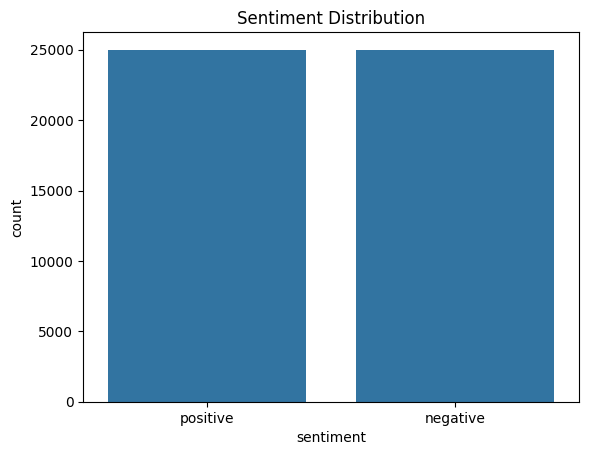

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nClass distribution:")
print(df["sentiment"].value_counts())

sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

Text Cleaning

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review_clean"] = df["review"].astype(str).apply(clean_text)

Tokenization & Padding

In [31]:
#Label Encoding
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
assert df["label"].isnull().sum() == 0, "Label mapping failed!"

max_words = 10000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["review_clean"])

X = tokenizer.texts_to_sequences(df["review_clean"])
X = pad_sequences(X, maxlen=max_len)

y = df["label"].values

Split

In [32]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

Build the 1D CNN model

In [33]:
model = Sequential()

# Embedding
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# Convolution layers (deeper CNN)
model.add(Conv1D(128, 5, activation="relu"))
model.add(Conv1D(128, 5, activation="relu"))

# Pooling
model.add(GlobalMaxPooling1D())

# Dense layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))

# Output
model.add(Dense(1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [34]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train it with early Stopping so it doesn't overfit

In [35]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 309ms/step - accuracy: 0.7356 - loss: 0.4926 - val_accuracy: 0.8681 - val_loss: 0.3171
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 312ms/step - accuracy: 0.8954 - loss: 0.2667 - val_accuracy: 0.8831 - val_loss: 0.2879
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 315ms/step - accuracy: 0.9399 - loss: 0.1705 - val_accuracy: 0.8857 - val_loss: 0.3128
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 317ms/step - accuracy: 0.9682 - loss: 0.0963 - val_accuracy: 0.8773 - val_loss: 0.3614


Plot training curves

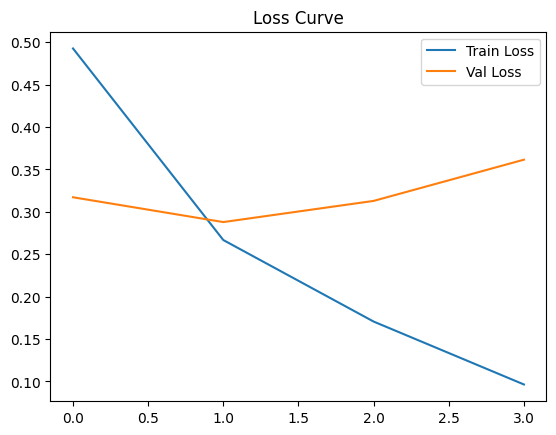

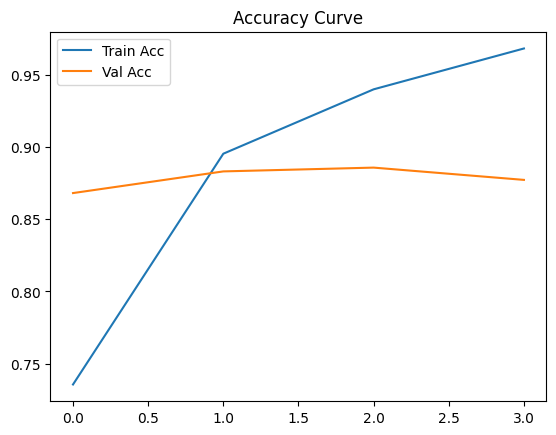

In [36]:
# Loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Accuracy
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Evaluation on Test set

In [37]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred.flatten() == y_test)
print("Test Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step
Test Accuracy: 0.8818
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      5000
           1       0.85      0.93      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Confusion Matrix

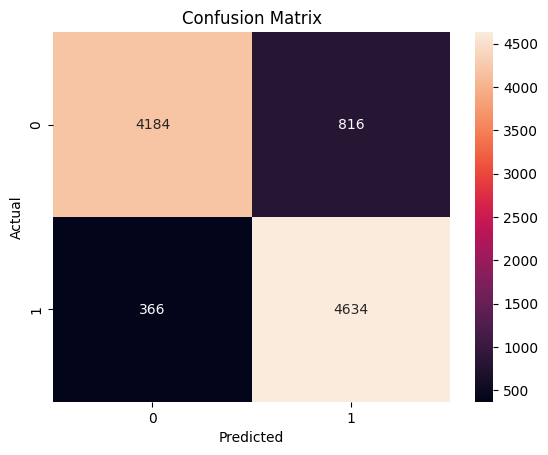

In [38]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Saving the results

In [39]:
import os

os.makedirs("results", exist_ok=True)

# Save my metrics
with open("metrics.txt", "w") as f:
    f.write(classification_report(y_test, y_pred))

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.savefig("confusion_matrix.png")
plt.close()